PYTHON: /media/monte_share/conda_envs/dataproc/bin/python
LD_LIBRARY_PATH: None
CONDA_PREFIX: /media/monte_share/conda_envs/dataproc


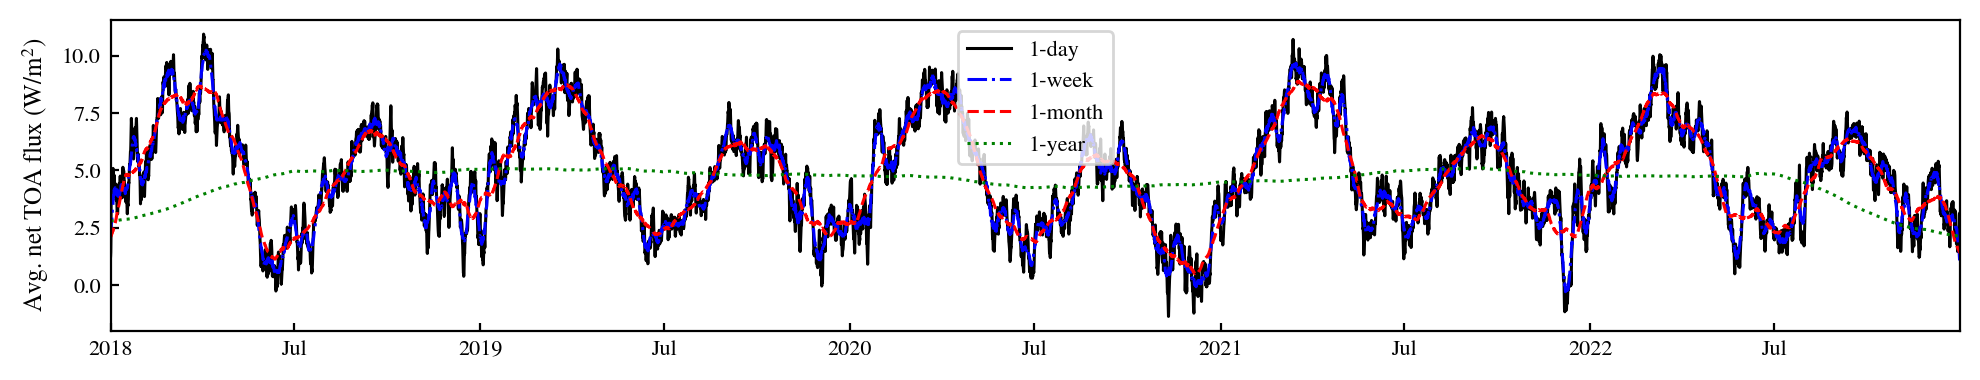

In [1]:
import numpy as np
from SpaceBalls.postproc_EEI_estimation import get_true_EEI_time_series
from SpaceBalls.radiation_fluxes_preprocessing import get_EEI_truth_daily_jd_arrays
from SpaceBalls.utils import normal_smoother
from SpaceBalls.plotter import Plotter
%matplotlib inline

EEI_name = "EEI_truth_1"
full_jd_array = np.concatenate(get_EEI_truth_daily_jd_arrays(EEI_name))

EEI_time_series_180x360 = get_true_EEI_time_series(EEI_name, 360, 180)
EEI_time_series_180x360_smooth = normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=1, out_length_mode='same')

smoothing_windows_days = [1, 7, 30, 365]
smoothing_windows_names = ['1-day', '1-week', '1-month', '1-year']
EEI_smooth_time_series_array = [normal_smoother(EEI_time_series_180x360, full_jd_array, window_width_days=window, out_length_mode='same') for window in smoothing_windows_days]

EEI_time_series_360x720 = get_true_EEI_time_series(EEI_name, 720, 360)
EEI_time_series_360x720_smooth = normal_smoother(EEI_time_series_360x720, full_jd_array, window_width_days=1, out_length_mode='same')

EEI_smooth_dict = {window_name: EEI_smooth for (window_name, EEI_smooth) in zip(smoothing_windows_names, EEI_smooth_time_series_array)}
Plotter.plot_time_series(full_jd_array,
                        EEI_smooth_dict,
                        f_width=2.5, f_height=0.5,
                        ylabel='Avg. net TOA flux (W/m$^2$)')



<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_746980/3970031479.py:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  y_scatter_dict={'$\phi(t)$ (W/m$^2$)': (full_jd_array,EEI_time_series_180x360)},


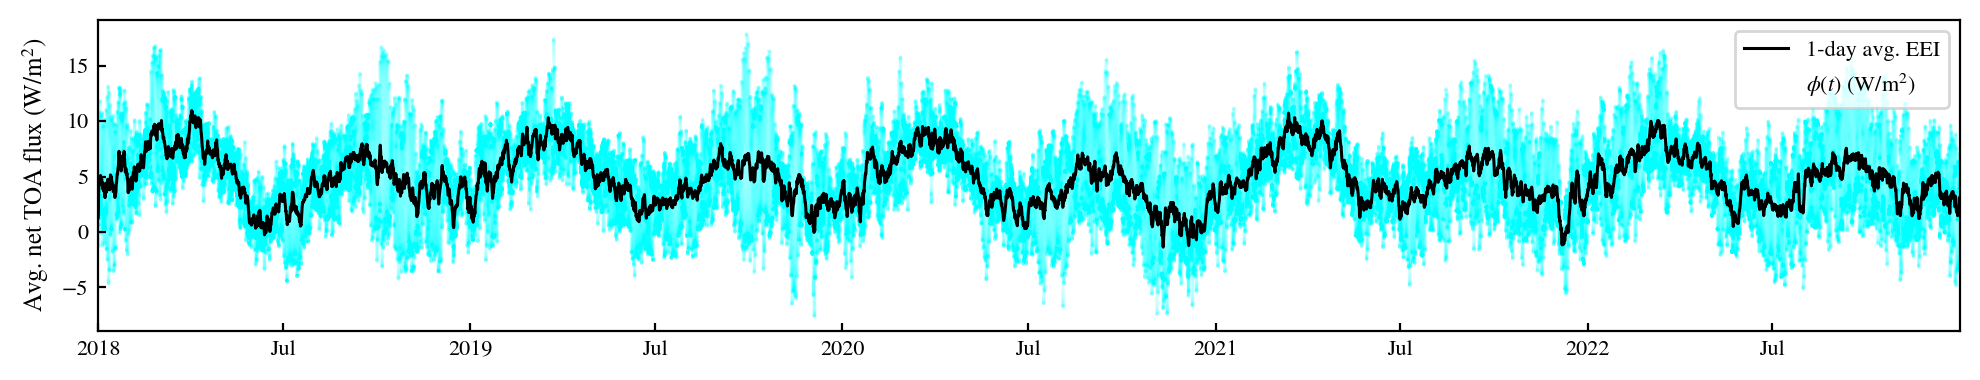

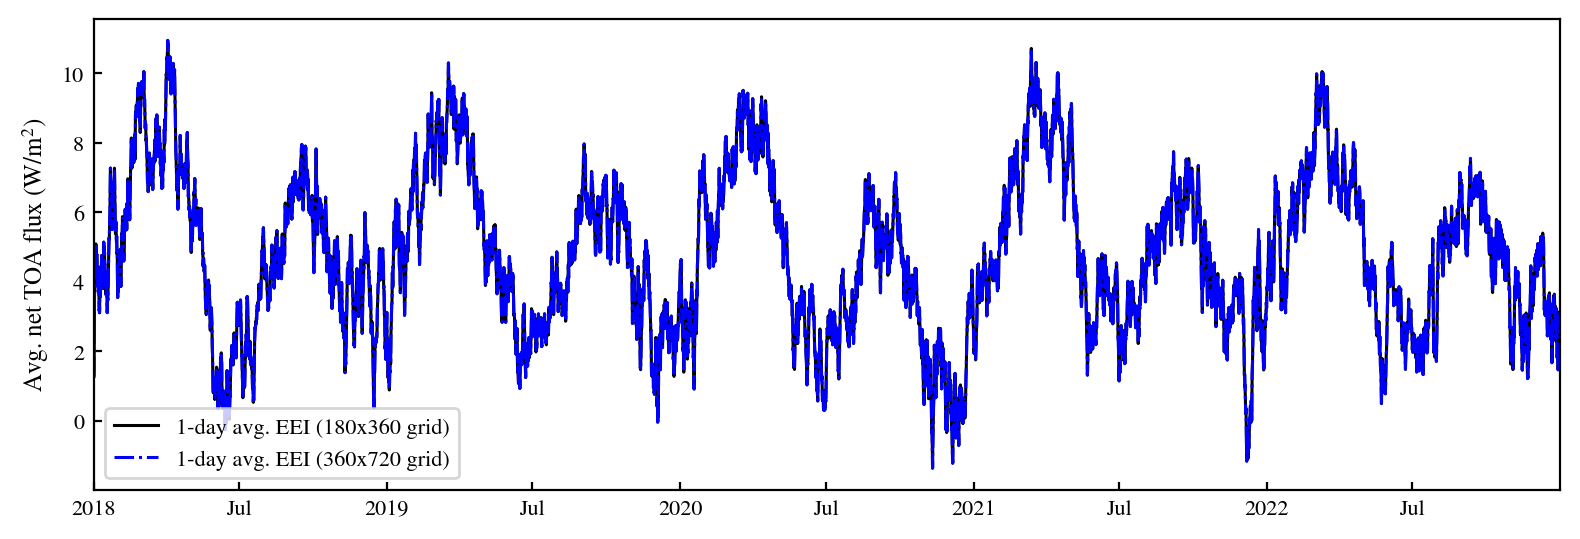

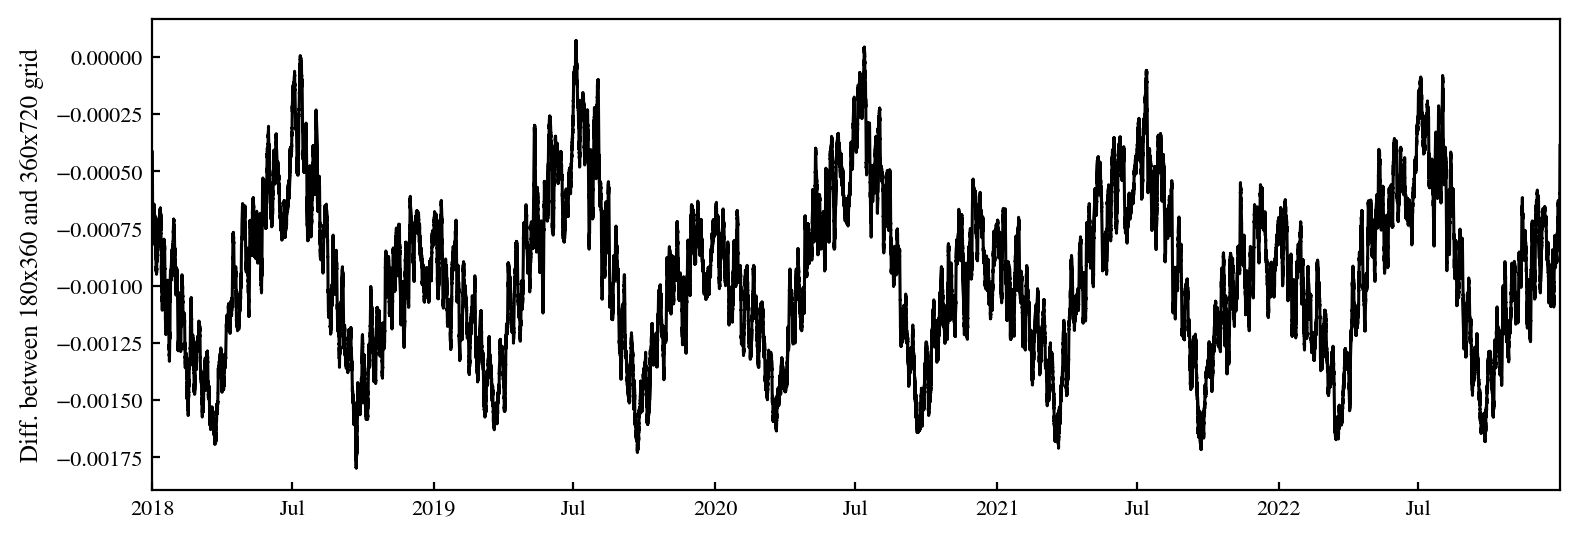

In [2]:
Plotter.plot_time_series(full_jd_array,
                         {'1-day avg. EEI': EEI_time_series_180x360_smooth},
                          f_width=2.5, f_height=0.5,
                          ylabel='Avg. net TOA flux (W/m$^2$)',
                          y_scatter_dict={'$\phi(t)$ (W/m$^2$)': (full_jd_array,EEI_time_series_180x360)},
                          scatter_alpha=0.007)

Plotter.plot_time_series(full_jd_array,
                         {'1-day avg. EEI (180x360 grid)': EEI_time_series_180x360_smooth,
                          '1-day avg. EEI (360x720 grid)': EEI_time_series_360x720_smooth},
                          f_width=2, f_height=0.7,
                          ylabel='Avg. net TOA flux (W/m$^2$)')

Plotter.plot_time_series(full_jd_array,
                         {'Diff. between 180x360 and 360x720 grid': EEI_time_series_180x360_smooth - EEI_time_series_360x720_smooth},
                          f_width=2, f_height=0.7,
                          ylabel='Diff. between 180x360 and 360x720 grid')

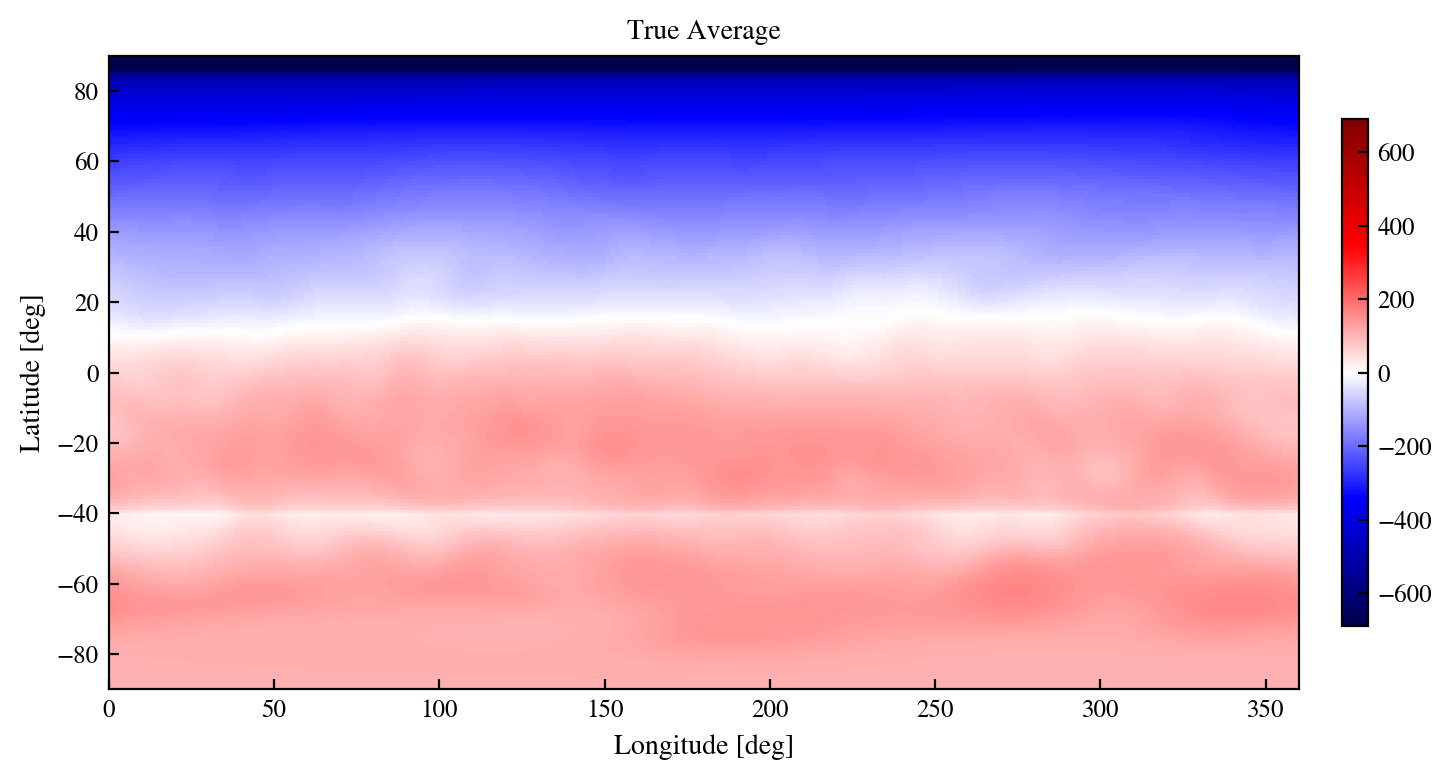

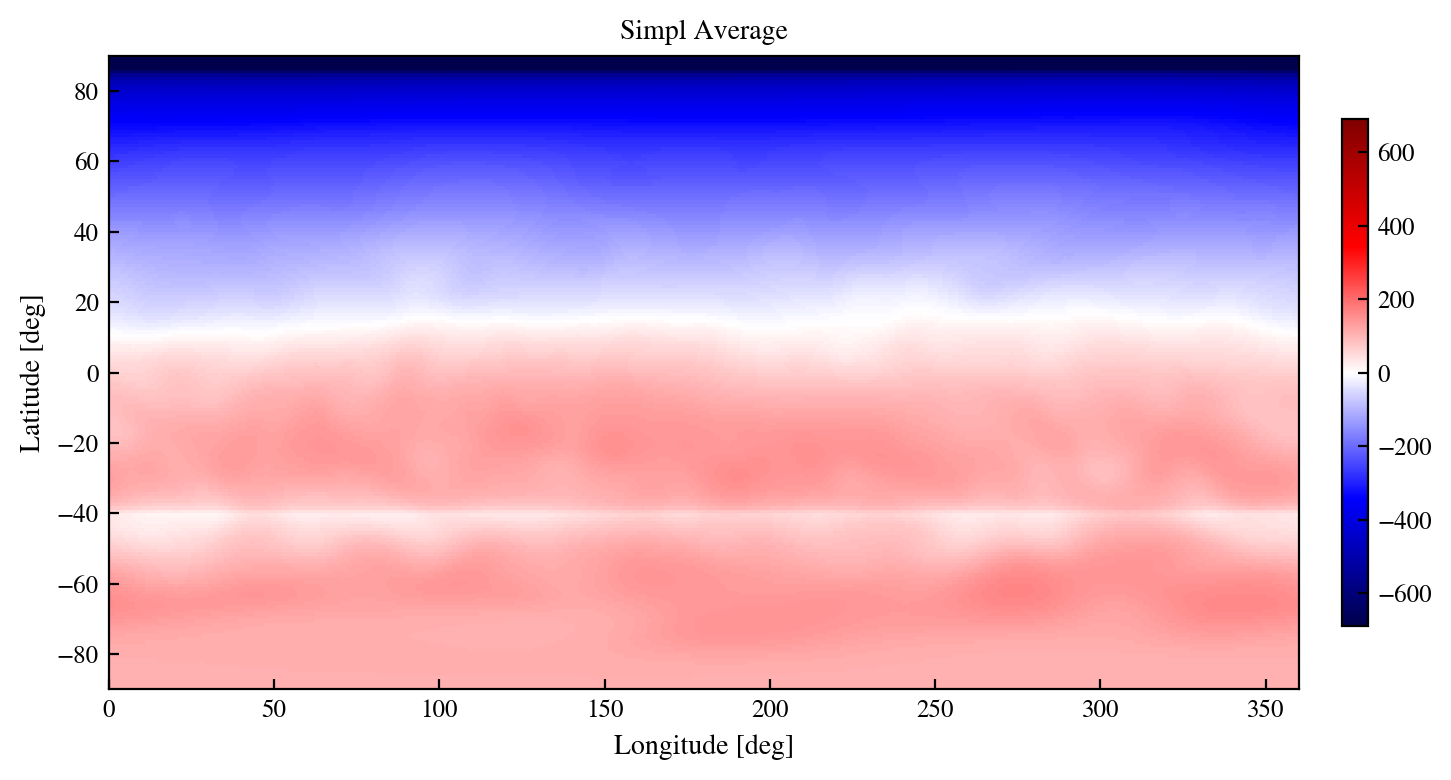

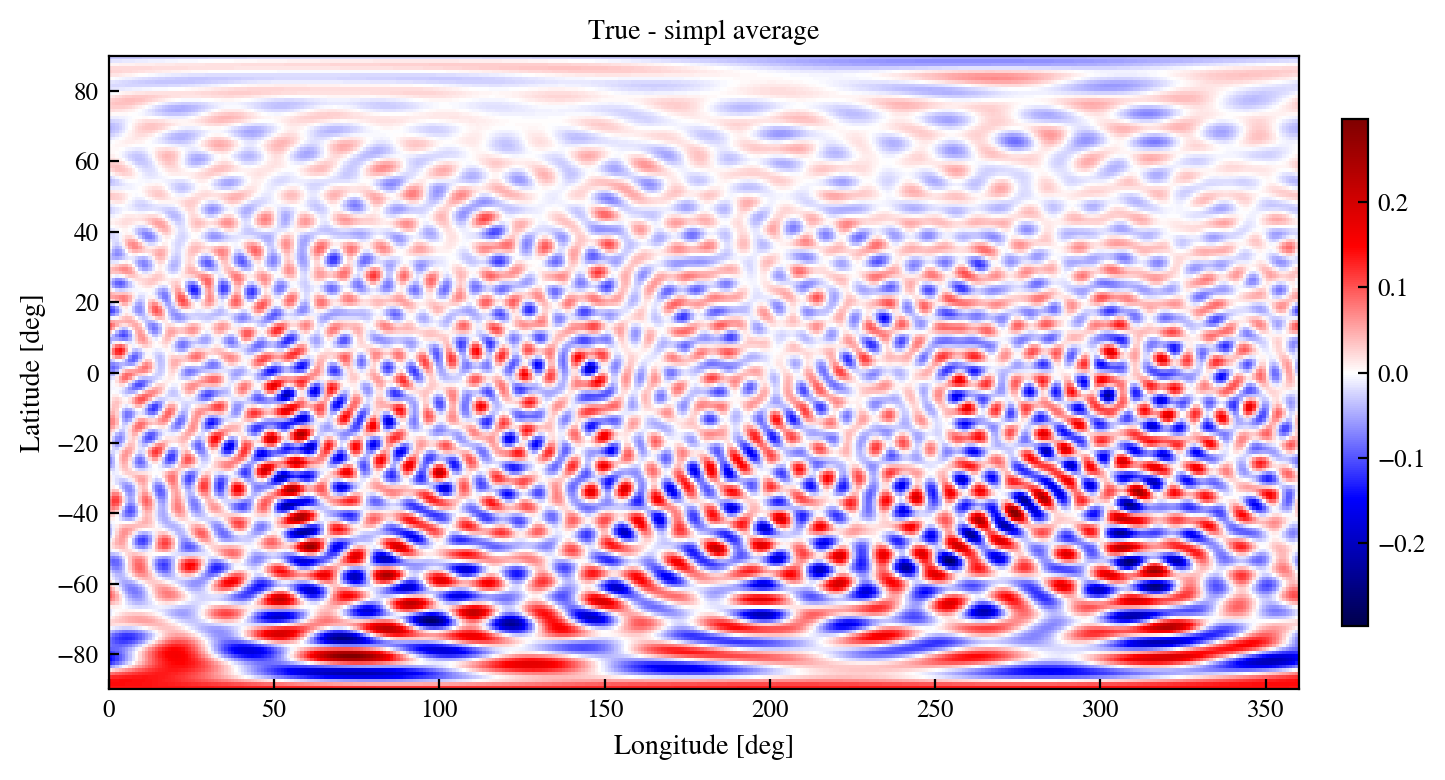

In [3]:
import sys, os
import numpy as np
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import get_sphere_grid
from SpaceBalls.radiation_fluxes_preprocessing import get_file_names_and_existence
%matplotlib inline

EEI_truth_name = "EEI_truth_1"
n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
out_dir = os.path.join(MEDIA_DIR, 'true_EEI', EEI_truth_name, 'grid_'+str(n_lat)+'x'+str(n_lon))

day_idx = 0
file_names, file_existences = get_file_names_and_existence(out_dir, 800, day_idx)

true_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km']+'.npy'))
simpl_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km_simpl1']+'.npy'))

Plotter.plot_geo_data(true_avg, lon_edges_vec, lat_edges_vec, title="True Average")
Plotter.plot_geo_data(simpl_avg, lon_edges_vec, lat_edges_vec, title="Simpl Average")
Plotter.plot_geo_data(true_avg - simpl_avg, lon_edges_vec, lat_edges_vec, title="True - simpl average")

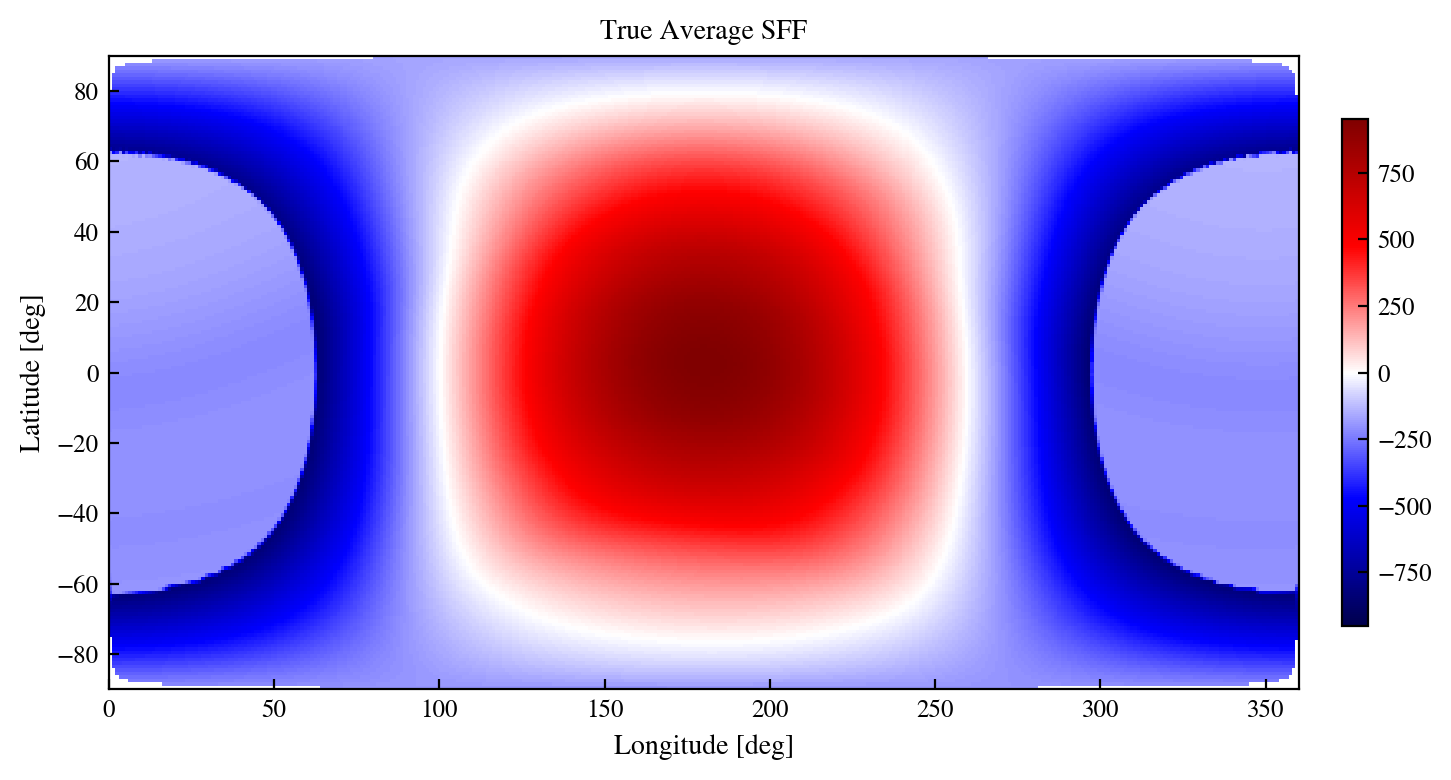

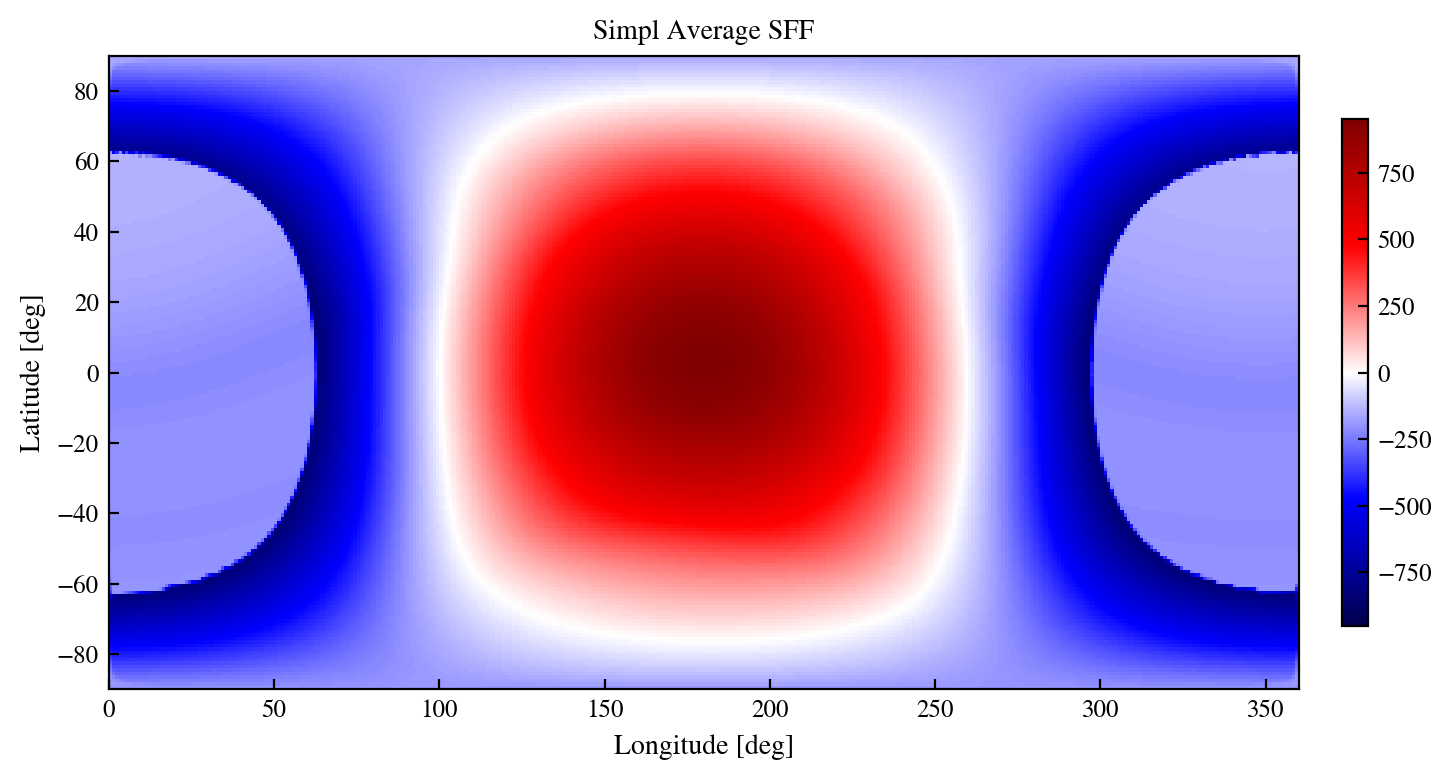

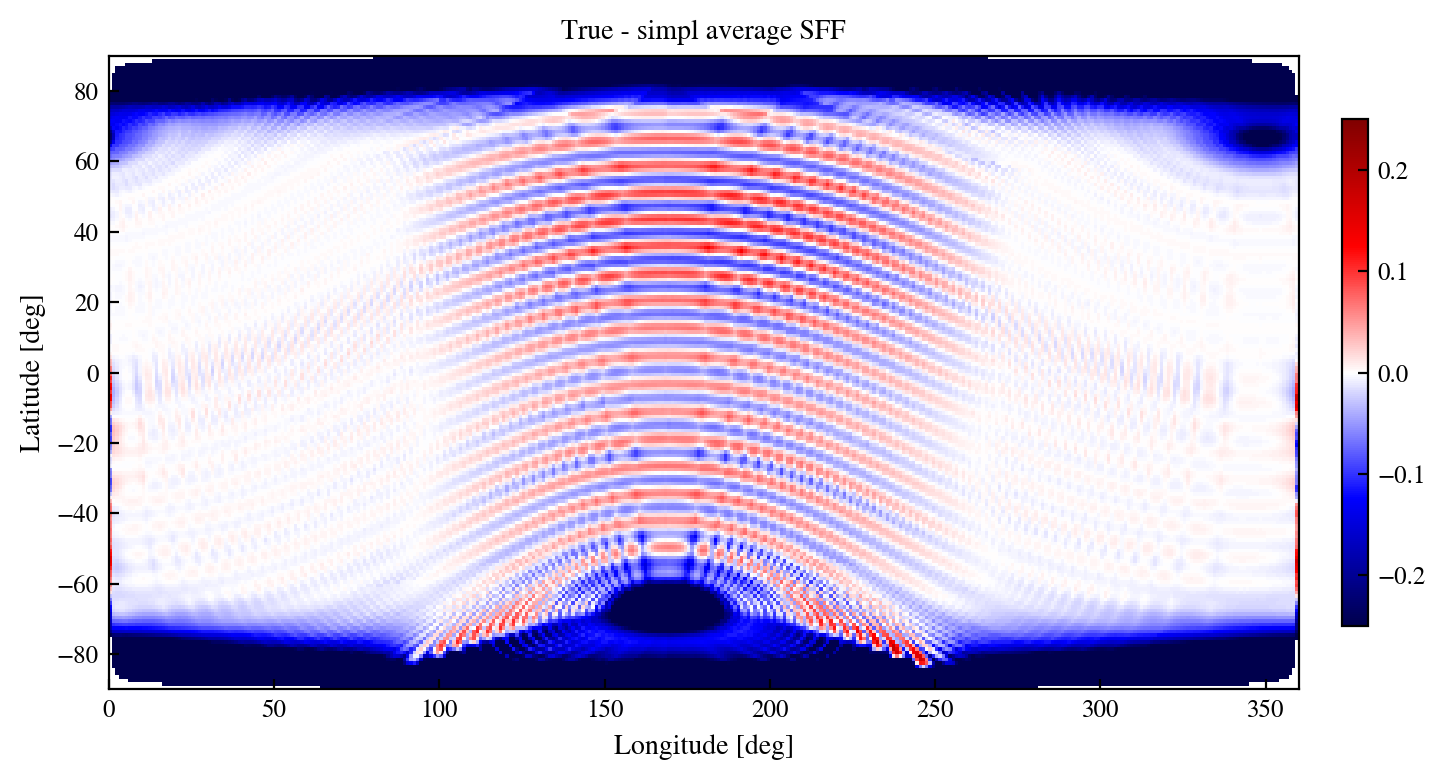

In [4]:
true_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km_SFF']+'.npy'))
simpl_avg = np.load(os.path.join(out_dir, file_names['daily_avg_net_800km_simpl1_SFF']+'.npy'))

Plotter.plot_geo_data(true_avg, lon_edges_vec, lat_edges_vec, title="True Average SFF")
Plotter.plot_geo_data(simpl_avg, lon_edges_vec, lat_edges_vec, title="Simpl Average SFF")
Plotter.plot_geo_data(true_avg - simpl_avg, lon_edges_vec, lat_edges_vec, title="True - simpl average SFF",
                      max_mag=0.25)

/media/monte_share/true_EEI/EEI_truth_1/grid_180x360/daily_hist_net_800km/day_0
(64800, 1440)
/media/monte_share/true_EEI/EEI_truth_1/grid_180x360/daily_hist_net_800km_SFF/day_0
/media/monte_share/true_EEI/EEI_truth_1/grid_180x360/daily_avg_net_800km/day_0
/media/monte_share/true_EEI/EEI_truth_1/grid_180x360/daily_avg_net_800km_SFF/day_0
/media/monte_share/true_EEI/EEI_truth_1/grid_180x360/daily_avg_net_800km_simpl1/day_0
/media/monte_share/true_EEI/EEI_truth_1/grid_180x360/daily_avg_net_800km_simpl1_SFF/day_0


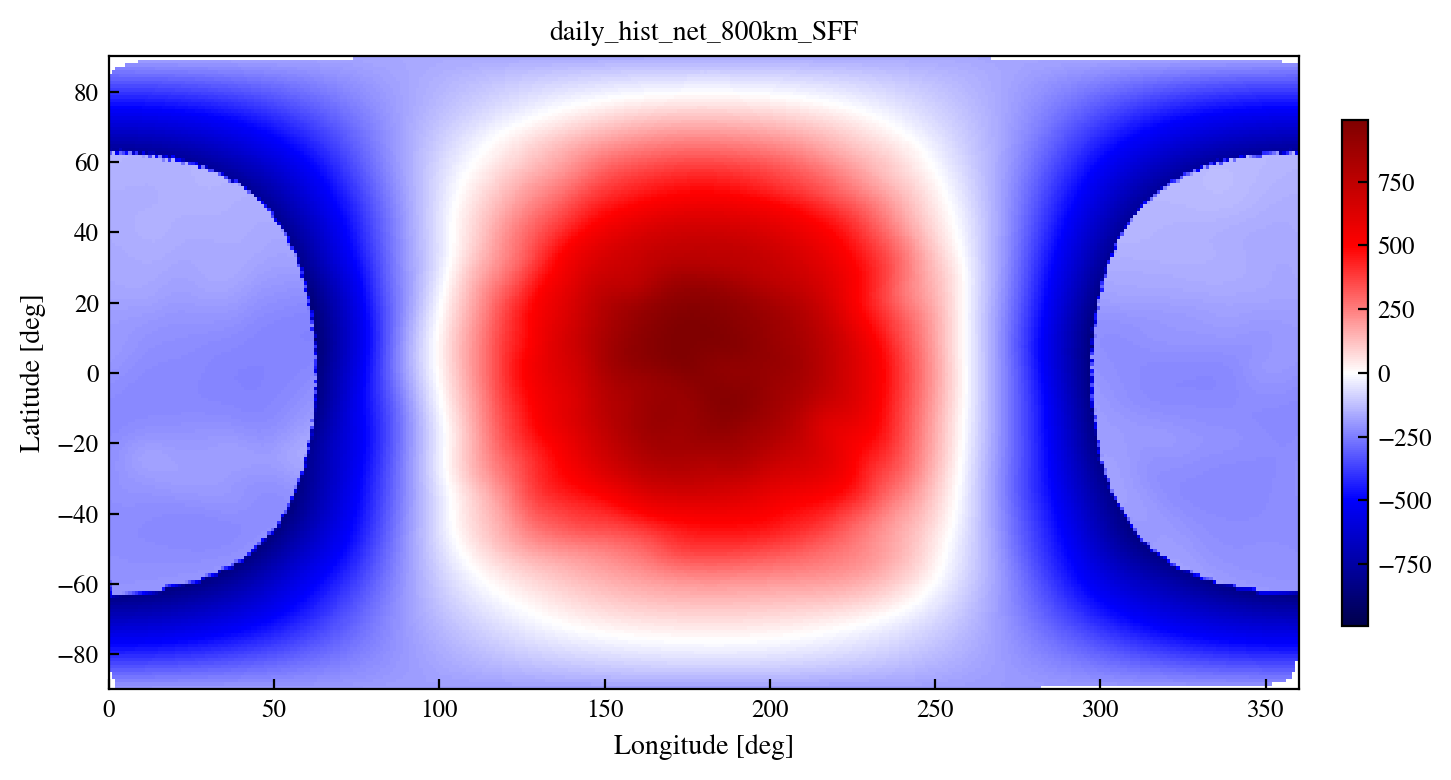

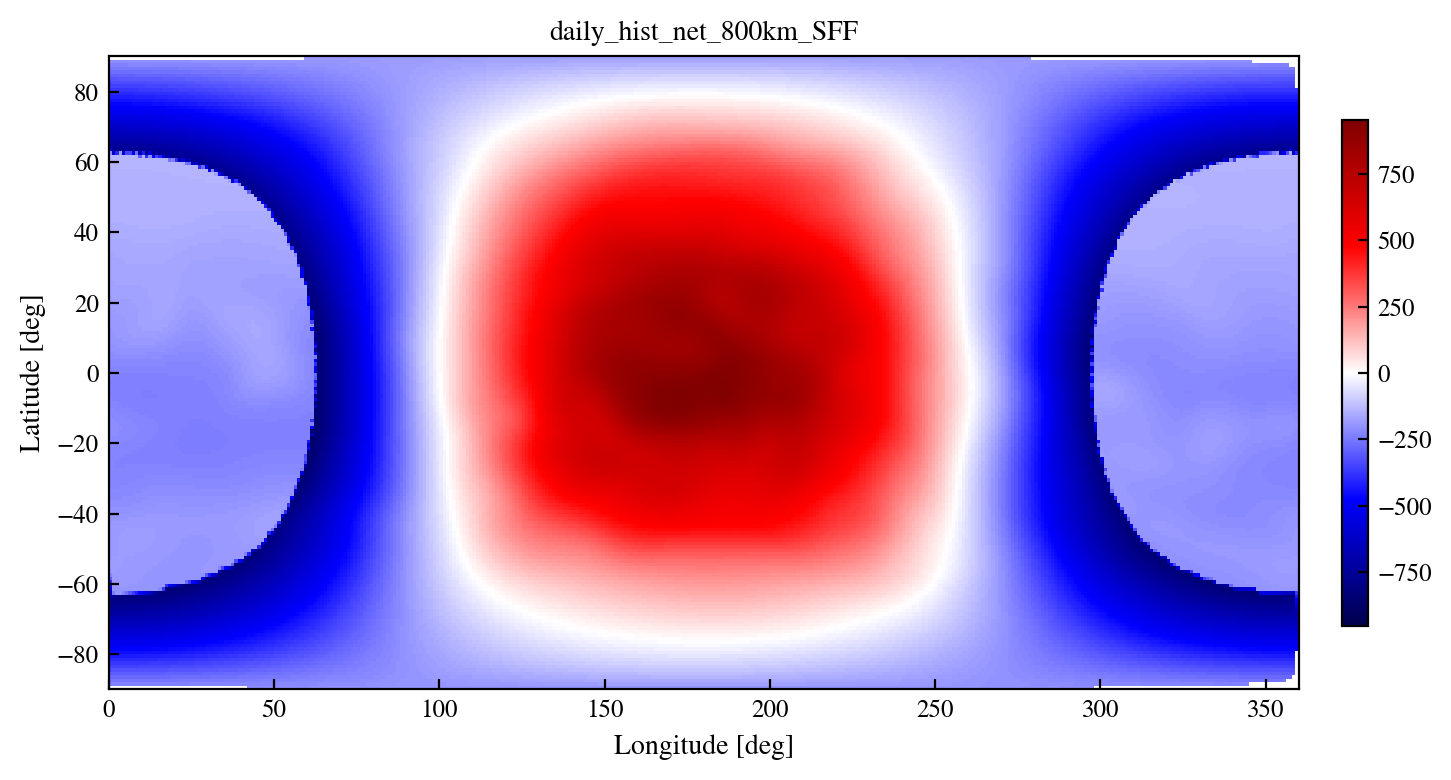

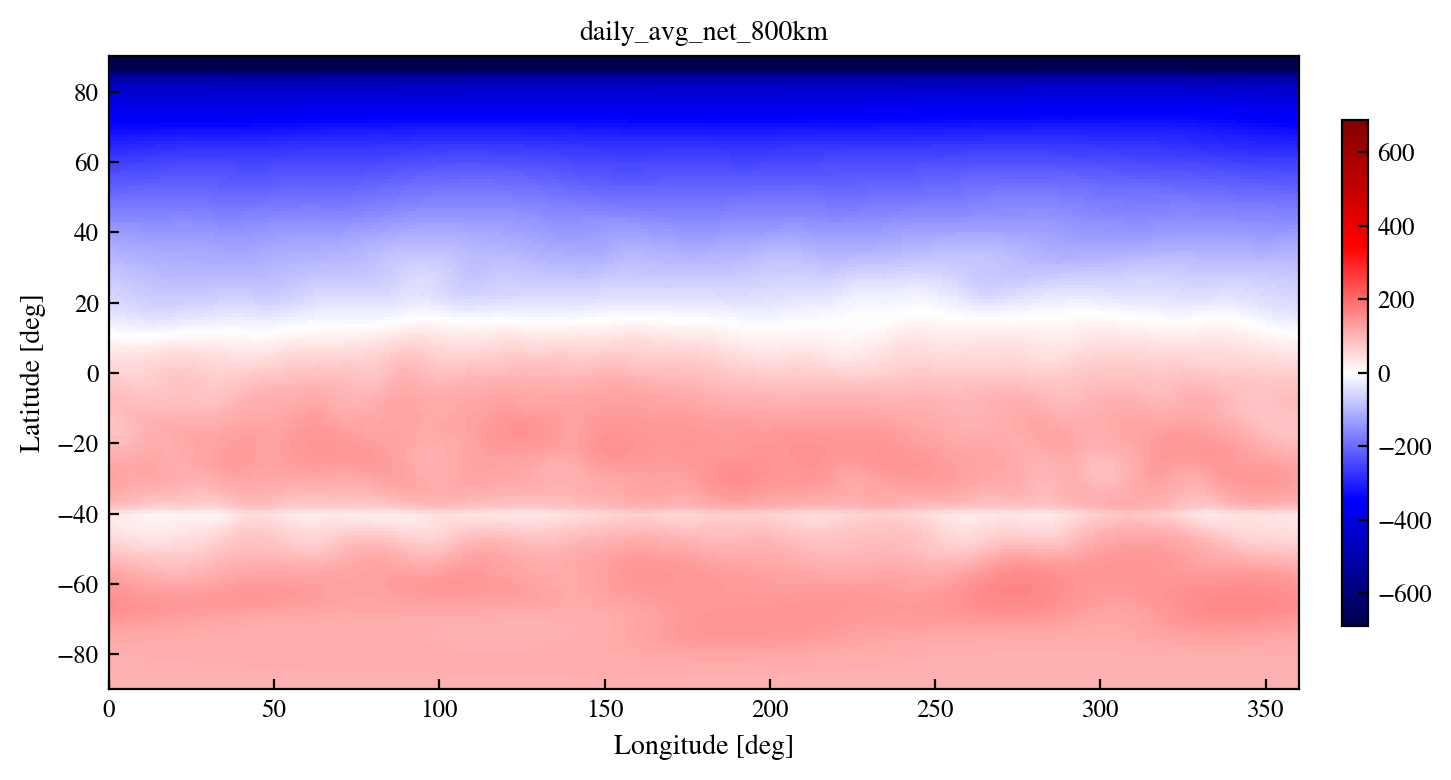

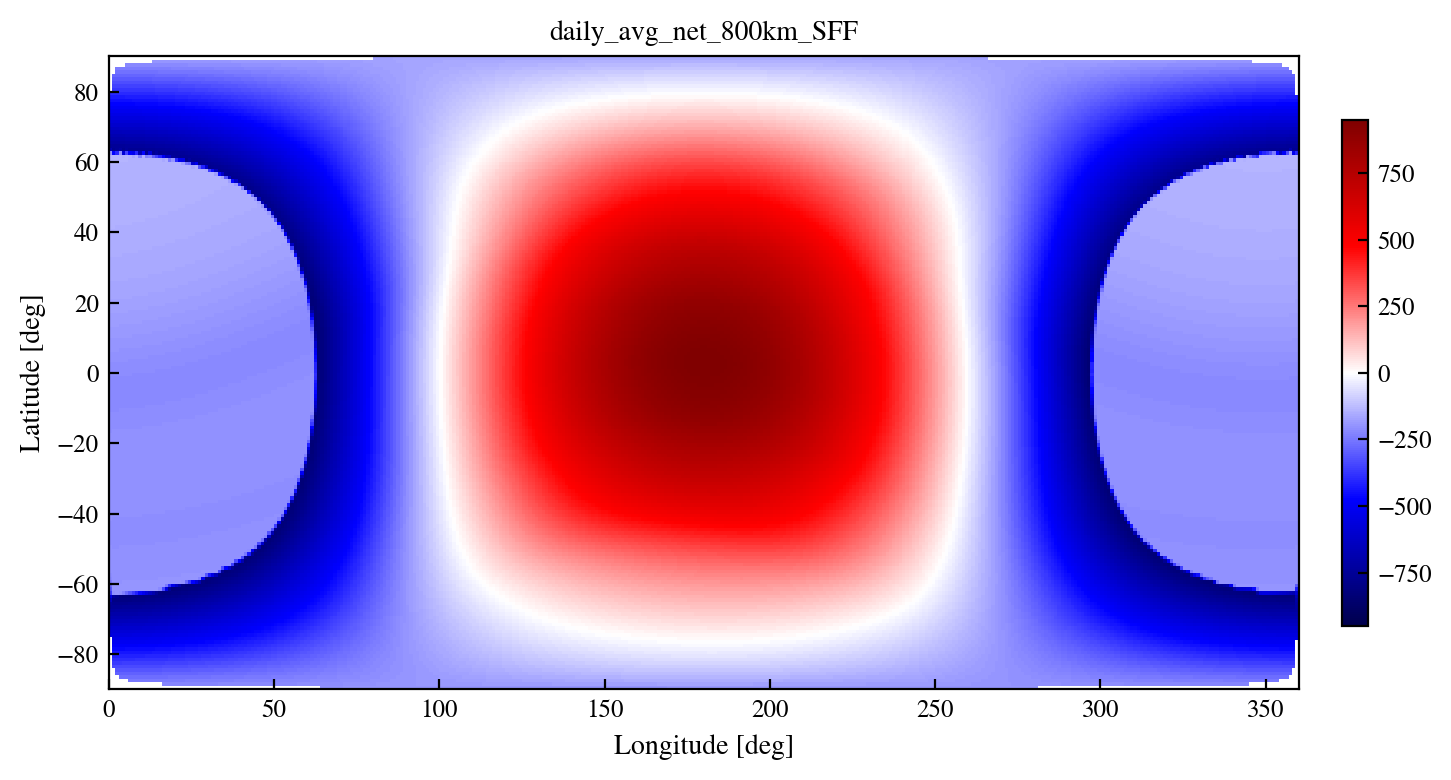

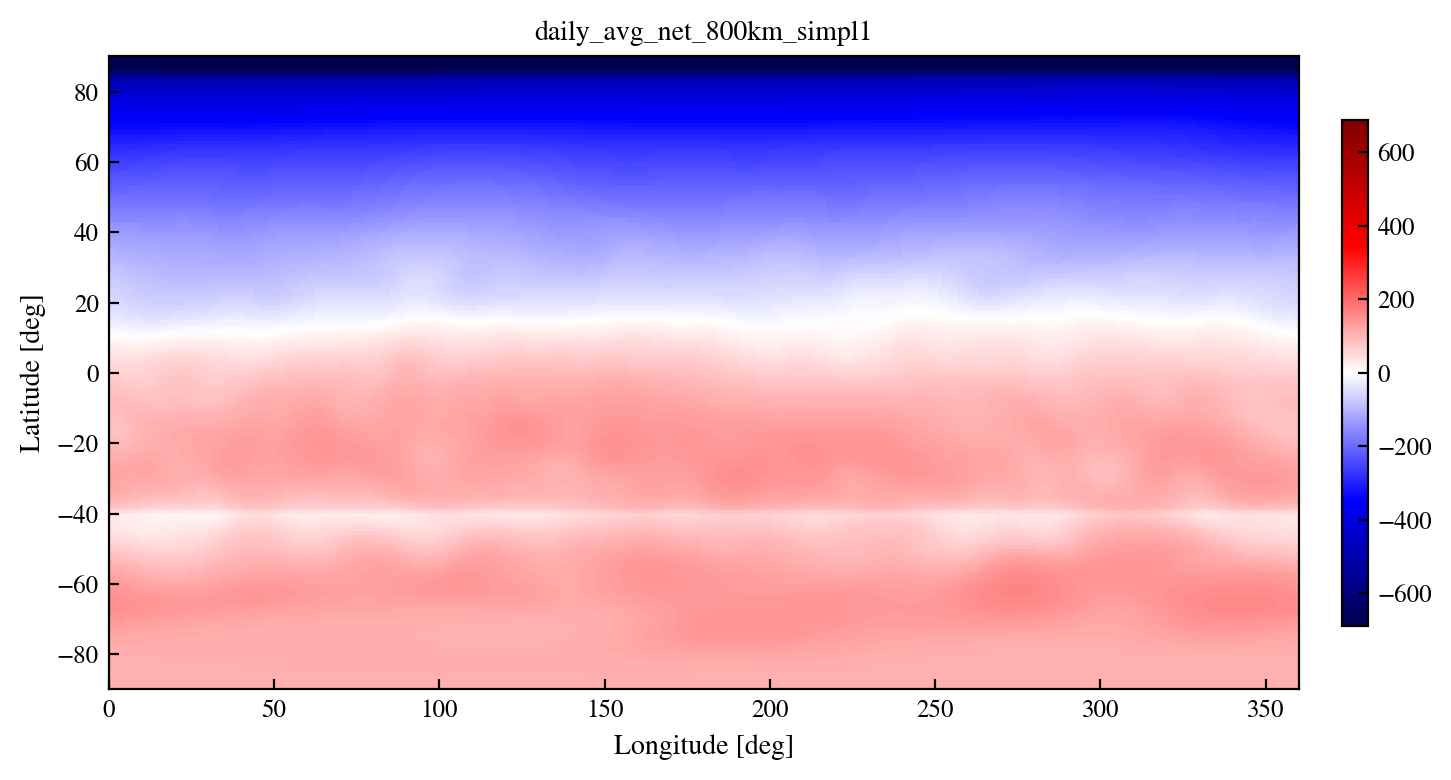

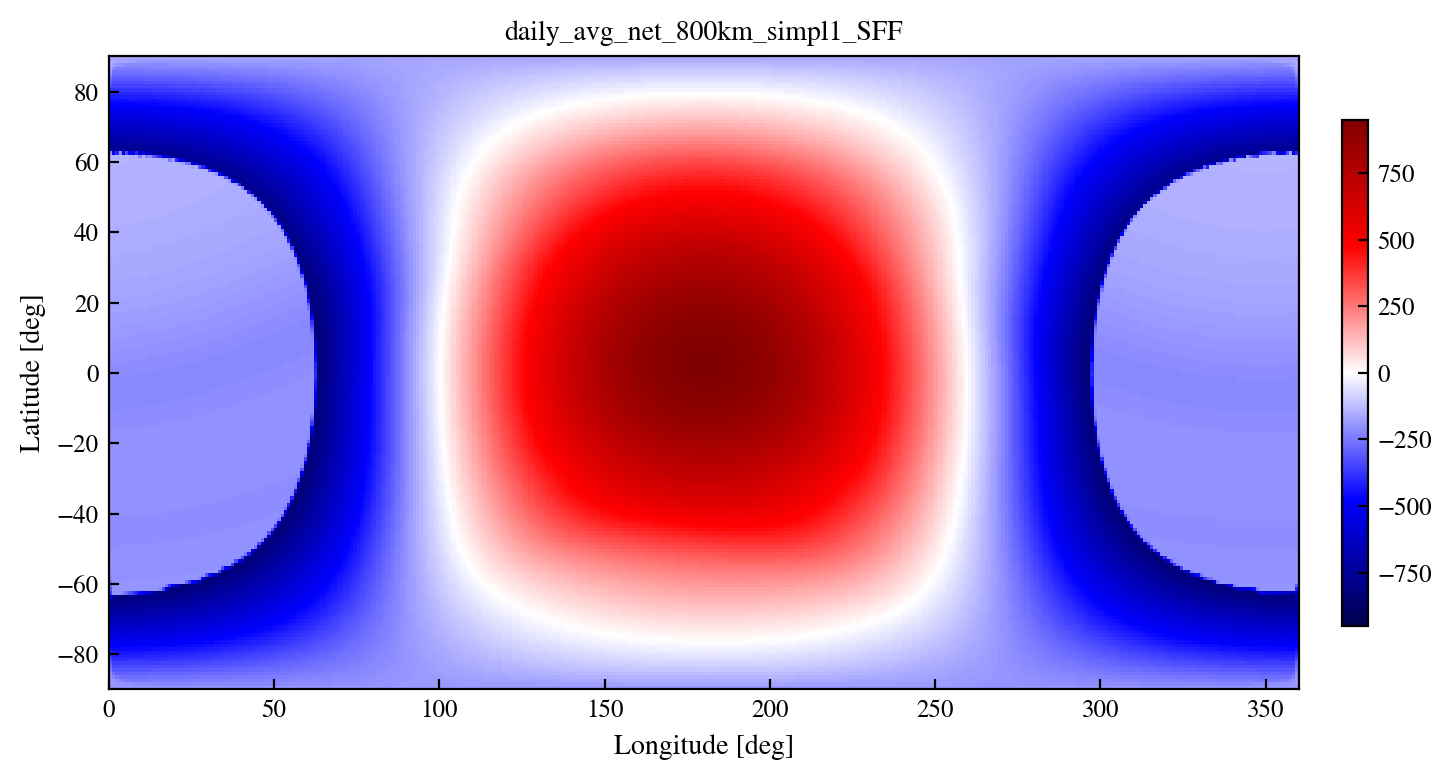

In [5]:
import sys, os
import numpy as np
from SpaceBalls.plotter import Plotter
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR
from SpaceBalls.sph_meshing import get_sphere_grid
from SpaceBalls.radiation_fluxes_preprocessing import get_file_names_and_existence
%matplotlib inline

EEI_truth_name = "EEI_truth_1"
n_lon, n_lat = 360, 180
lon_vec, lat_vec, lon_edges_vec, lat_edges_vec = get_sphere_grid(n_lon, n_lat)
out_dir = os.path.join(MEDIA_DIR, 'true_EEI', EEI_truth_name, 'grid_'+str(n_lat)+'x'+str(n_lon))

# TOA
day_idx = 0
file_names, file_existences = get_file_names_and_existence(out_dir, 800, day_idx)
#del(file_names['daily_hist_net_toa_lat_avg'])
#del(file_names['daily_hist_net_toa_surf_avg'])

for fkey, fname in file_names.items():
    print(fname)
    if file_existences[fkey]:
        try:
            map = np.load(fname+'.npy')
        except:
            map = np.loadtxt(fname+'.txt')
            if len(map)>n_lon*n_lat:
                map = map.reshape((n_lat, n_lon, 1440))

        if len(np.shape(map))==3:
            Plotter.plot_geo_data(map[:,:,0], lon_edges_vec, lat_edges_vec, title=fkey)
            Plotter.plot_geo_data(map[:,:,700], lon_edges_vec, lat_edges_vec, title=fkey)
        elif len(np.shape(map))==2 and np.shape(map)==(n_lat, n_lon):
            Plotter.plot_geo_data(map, lon_edges_vec, lat_edges_vec, title=fkey)
        else:
            print(np.shape(map))

